# 03 Models
- Logistic 
- Random Forest 
- XGBoost or Gradient Boosting	
## Objective
To train supervised machine learning baseline models for credit card fraud detection.
- Goal: To compare traditional supervised models before developing the Autoencoder anomaly detection model.

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score, 
    roc_curve,
    precision_recall_curve

)

# Load Processed dataset


In [2]:
data_path = Path("../outputs/results/creditcard_cleaned.pk1")
data = joblib.load(data_path)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


# Evaluation Function

In [3]:
def evaluate_model(model_name, y_true, y_proba, threshold =0.5):
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        "Model":model_name,
        "Threshold":threshold,
        "precision":precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "ROC_AUC":roc_auc_score(y_true, y_proba),
        "PRO-AUC": average_precision_score(y_true, y_proba)
    }
    print(f"\n====={model_name}=====")
    print(f"Theshold:{threshold}")
    print("\nClassification Report:")
    print(f"{classification_report(y_true, y_pred)}")

    print("Confusion Matrix:")
    print(f"{confusion_matrix(y_true, y_pred)}")

    return results

# 1.Logistic Regression

In [4]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42)

log_model.fit(X_train, y_train)

log_proba = log_model.predict_proba(X_test)[:, 1]

log_results = evaluate_model("Logistic Regression",
                             y_test,
                             log_proba,
                             threshold=0.5)


=====Logistic Regression=====
Theshold:0.5

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Confusion Matrix:
[[55258  1393]
 [   12    83]]


# 2Random Forest

In [5]:
rf_model = RandomForestClassifier(n_estimators=200,
                                  class_weight="balanced",
                                  random_state=42,
                                  n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:,1]

rf_results = evaluate_model("Random Forest",
                            y_test,
                            rf_proba,
                            threshold=0.5)


=====Random Forest=====
Theshold:0.5

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56649     2]
 [   27    68]]


In [6]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_proba =gb_model.predict_proba(X_test)[:,1]

gb_results = evaluate_model("Gradient Boosting",
                            y_test,
                            gb_proba,
                            threshold=0.5
                            )



=====Gradient Boosting=====
Theshold:0.5

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.65      0.74        95

    accuracy                           1.00     56746
   macro avg       0.93      0.83      0.87     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56641    10]
 [   33    62]]


# Results Comparison

In [7]:
results_df = pd.DataFrame([log_results, rf_results, gb_results])

results_df

,Model,Threshold,precision,Recall,f1_score,ROC_AUC,PRO-AUC
0,Logistic Regression,0.5,0.056233,0.873684,0.105665,0.965839,0.671935
1,Random Forest,0.5,0.971429,0.715789,0.824242,0.944681,0.808755
2,Gradient Boosting,0.5,0.861111,0.652632,0.742515,0.853926,0.623354


# Tuning Threshold

In [11]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
threshold_results = []

for threshold in thresholds:
    threshold_results.append( 
                            evaluate_model("Random Forest",
                            y_test,
                            rf_proba,
                            threshold=threshold
                            )
                            )
    
threshold_df = pd.DataFrame(threshold_results)

threshold_df


=====Random Forest=====
Theshold:0.1

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56640    11]
 [   19    76]]

=====Random Forest=====
Theshold:0.2

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.78      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56645     6]
 [   21    74]]

=====Random Forest=====
Theshold:0.3

Classification Report:
              precision    recall  f1-score   support

       

,Model,Threshold,precision,Recall,f1_score,ROC_AUC,PRO-AUC
0,Random Forest,0.1,0.873563,0.800000,0.835165,0.944681,0.808755
1,Random Forest,0.2,0.925000,0.778947,0.845714,0.944681,0.808755
2,Random Forest,0.3,0.958904,0.736842,0.833333,0.944681,0.808755
3,Random Forest,0.4,0.958333,0.726316,0.826347,0.944681,0.808755
4,Random Forest,0.5,0.971429,0.715789,0.824242,0.944681,0.808755


# Plots

# ROC Curve

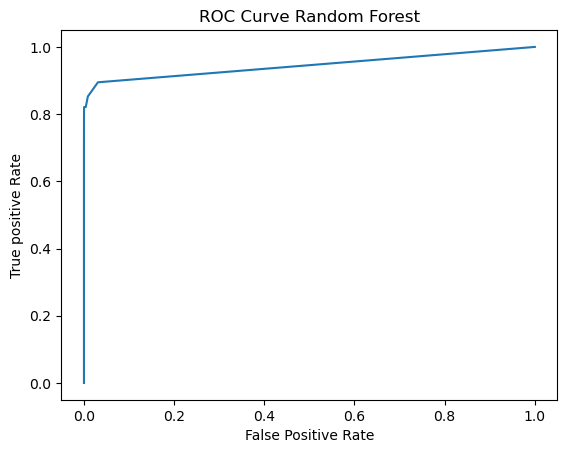

In [14]:
fpr,tpr, _ = roc_curve(y_test, rf_proba)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True positive Rate")
plt.title("ROC Curve Random Forest")
plt.show()

# Precision Recall Curve

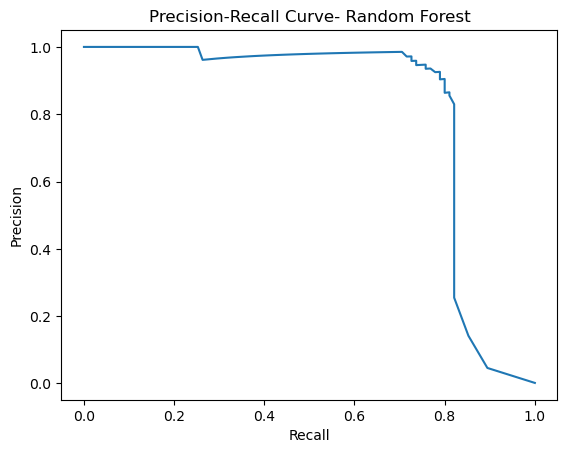

In [15]:
precision, recall, _ = precision_recall_curve(y_test, rf_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve- Random Forest")
plt.show()

In [12]:
output_path = Path("../outputs/results")
output_path.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_path / "baseline_model_results.csv", index=False)
threshold_df.to_csv(output_path / "threshold_tuning_results.csv", index=False)

joblib.dump(
    {
        "logistic_regression": log_model,
        "random_forest": rf_model,
        "gradient_boosting": gb_model
    },
    output_path / "baseline_models.pkl"
)

print("Baseline results and models saved successfully.")

Baseline results and models saved successfully.


## Baseline Models Summary

Three supervised baseline models were trained:

- Logistic Regression
- Random Forest
- Gradient Boosting

The models were evaluated using fraud-focused metrics including precision, recall, F1-score, ROC-AUC, and PR-AUC.

Accuracy was not used as the main metric because the dataset is highly imbalanced.
Threshold tuning was also performed to observe how fraud detection performance changes when the classification threshold is adjusted.

Lowering the classification threshold increases recall, allowing more fraudulent transactions to be detected. However, this comes at the cost of reduced precision, leading to more false positives.

In fraud detection systems, recall is often prioritized to minimize financial losses, even if it results in an increased number of false alerts.

Among the baseline models, Random Forest achieved the best balance between precision and recall, making it the most suitable supervised model for fraud detection in this dataset.

Threshold tuning revealed that lowering the decision threshold improves recall at the expense of precision, which is desirable in fraud detection scenarios where missing fraudulent transactions is more costly than false positives.

However, due to the extreme class imbalance, supervised models still face limitations, motivating the use of anomaly detection techniques such as Autoencoders.

### 1. Why is Random Forest better than Logistic Regression here?
- Random Forest performs better because it captures complex non-linear relationships in the data and is less sensitive to feature scaling. 
- It also handles class imbalance more effectively when combined with class weights, leading to a better balance between precision and recall compared to linear models like Logistic Regression.

### 2. Why is lowering the threshold useful?
- Lowering the decision threshold increases the sensitivity of the model, allowing it to classify more transactions as fraudulent. 
-This improves recall but introduces more false positives. In fraud detection, this trade-off is acceptable because the cost of missing fraud is significantly higher than investigating false alerts.

### 3. Why are supervised models still limited?
- Supervised models are limited because they rely on labeled data, and in highly imbalanced datasets, they tend to bias predictions toward the majority class. 
- As a result, they may fail to learn meaningful patterns for rare fraudulent transactions, making them less effective at detecting novel or unseen fraud cases.